In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
import json
from pathlib import Path

from ipysigma import Sigma

import sys
import re
sys.path.append('../')
from source import Align
from textwrap import wrap

Text(0.5, 1.0, 'Databases Redudancy (>95% identity)')

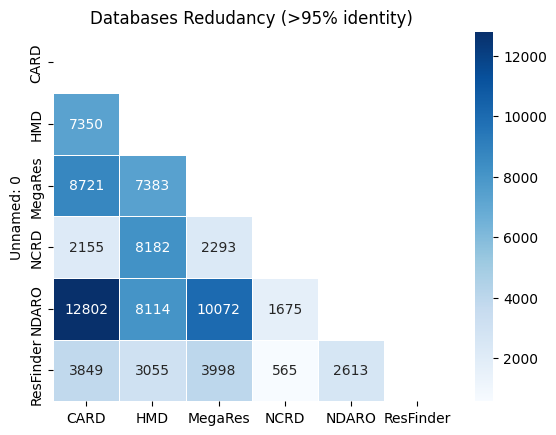

In [18]:
BlastPairWiseAlignmentPivoted = pd.read_csv("../data/processed/BlastPairWiseAlignmentPivoted.cov95.maxseq5.csv", sep="\t")
mask = np.triu(np.ones_like(BlastPairWiseAlignmentPivoted.set_index("Unnamed: 0"), dtype=bool)) 
sns.heatmap(
    BlastPairWiseAlignmentPivoted.set_index("Unnamed: 0"),
    cmap="Blues",
    annot=True,
    fmt=".0f",
    linewidth=.5,
    mask=mask,
)
plt.title("Databases Redudancy (>95% identity)")

In [19]:
BlastPairWiseAlignmentPivoted

,Unnamed: 0,CARD,HMD,MegaRes,NCRD,NDARO,ResFinder
0,CARD,5284,5209,7225,1447,7688,2212
1,HMD,7350,28815,7828,6213,5933,2665
2,MegaRes,8721,7383,4587,1562,6698,3188
3,NCRD,2155,8182,2293,5460,1982,605
4,NDARO,12802,8114,10072,1675,6643,2834
5,ResFinder,3849,3055,3998,565,2613,303


Text(0, 0.5, 'Database Size')

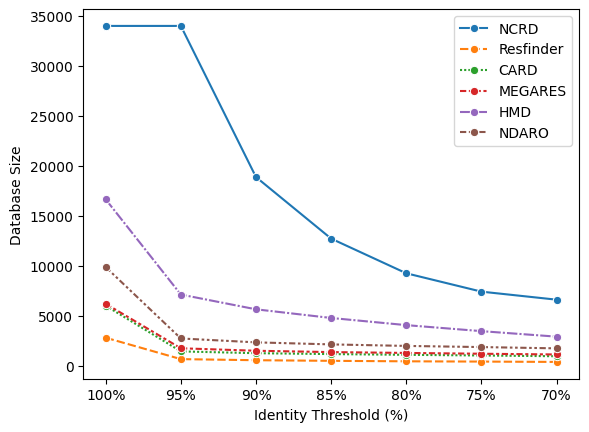

In [20]:
ClustersCdHit = pd.read_csv(
    "../data/processed/cdhitclusters.defaultsettings.csv",
    sep = "\t",
)
sns.lineplot(
    ClustersCdHit.set_index("Unnamed: 0"),
    marker = "o"
)
plt.xlabel("Identity Threshold (%)")
plt.ylabel("Database Size")

In [21]:
ClustersCdHit

,Unnamed: 0,NCRD,Resfinder,CARD,MEGARES,HMD,NDARO
0,100%,34008,2830,6027,6220,16666,9892
1,95%,34008,690,1462,1774,7147,2755
2,90%,18893,580,1283,1527,5670,2366
3,85%,12739,519,1194,1393,4805,2162
4,80%,9273,471,1120,1308,4089,2010
5,75%,7437,444,1053,1228,3487,1895
6,70%,6634,410,978,1155,2937,1766


In [23]:
PairWiseAlignment = pd.read_csv(
    "../data/filtered/AllDatabases.Paiwise.cov95.maxseq5.tsv", 
    sep = "\t",
    skipinitialspace=True, 
    header=None,
    names = "qseqid sseqid pident length qlen slen qstart qend sstart send evalue bitscore ppos full_qseq full_sseq".split(" ")
)
PairWiseAlignment["qcov"] = np.round((PairWiseAlignment["qend"] - PairWiseAlignment["qstart"] + 1) / (PairWiseAlignment["qlen"]) * 100, 2)
PairWiseAlignment["scov"] = np.round((PairWiseAlignment["send"] - PairWiseAlignment["sstart"] + 1) / (PairWiseAlignment["slen"]) * 100, 2)
PairWiseAlignment["qseqtag"] = PairWiseAlignment["qseqid"].str.split("|").str[1]
PairWiseAlignment["sseqtag"] = PairWiseAlignment["sseqid"].str.split("|").str[1]
PairWiseAlignment["qseqid"] = PairWiseAlignment["qseqid"].str.split("|").str[0]
PairWiseAlignment["sseqid"] = PairWiseAlignment["sseqid"].str.split("|").str[0]

In [24]:
PairWiseAlignment

,qseqid,sseqid,pident,length,qlen,slen,qstart,qend,sstart,send,evalue,bitscore,ppos,full_qseq,full_sseq,qcov,scov,qseqtag,sseqtag
0,CARD_0,MEGARES_1086,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.00,CARD,MEGARES
1,CARD_0,MEGARES_1087,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.00,CARD,MEGARES
2,CARD_0,NDARO_1066,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.00,CARD,NDARO
3,CARD_0,NCRD_32754,100.0,296,296,302,1,296,1,296,7.120000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,98.01,CARD,NCRD
4,CARD_0,HMD_10110,99.7,296,296,304,1,296,9,304,2.200000e-214,585.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MPLKEIEVMKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGK...,100.0,97.37,CARD,HMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363315,RESFINDER_2922,CARD_2551,100.0,241,241,241,1,241,1,241,2.470000e-177,487.0,100.0,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,100.0,100.00,RESFINDER,CARD
363316,RESFINDER_2922,MEGARES_948,100.0,241,241,241,1,241,1,241,2.470000e-177,487.0,100.0,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,100.0,100.00,RESFINDER,MEGARES
363317,RESFINDER_2922,NCRD_529,100.0,241,241,241,1,241,1,241,2.470000e-177,487.0,100.0,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,100.0,100.00,RESFINDER,NCRD
363318,RESFINDER_2922,NDARO_4176,100.0,241,241,241,1,241,1,241,2.470000e-177,487.0,100.0,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,100.0,100.00,RESFINDER,NDARO


<Axes: xlabel='qcov', ylabel='pident'>

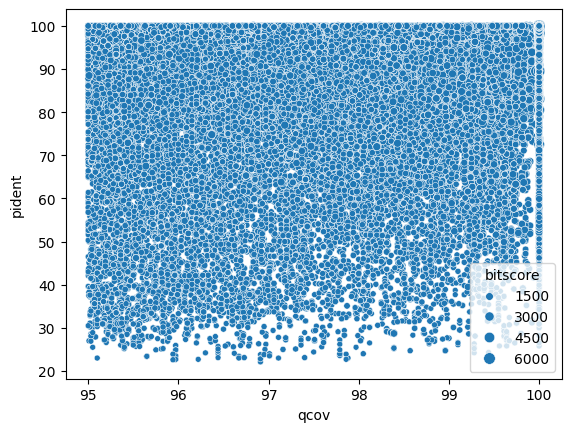

In [44]:
sns.scatterplot(
    data=PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 70], 
    x="qcov", 
    y="pident",
    size = "bitscore",
    )

<Axes: xlabel='pident', ylabel='ppos'>

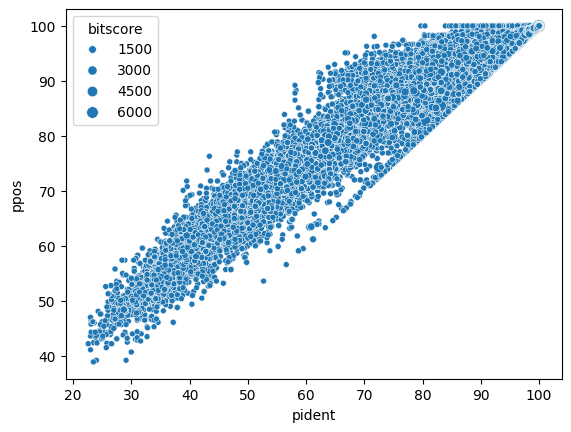

In [36]:
sns.scatterplot(
    data=PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 80], 
    x="pident", 
    y="ppos",
    size = "bitscore",
    )

In [27]:
PairWiseAlignment

,qseqid,sseqid,pident,length,qlen,slen,qstart,qend,sstart,send,evalue,bitscore,ppos,full_qseq,full_sseq,qcov,scov,qseqtag,sseqtag
0,CARD_0,MEGARES_1086,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.00,CARD,MEGARES
1,CARD_0,MEGARES_1087,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.00,CARD,MEGARES
2,CARD_0,NDARO_1066,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.00,CARD,NDARO
3,CARD_0,NCRD_32754,100.0,296,296,302,1,296,1,296,7.120000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,98.01,CARD,NCRD
4,CARD_0,HMD_10110,99.7,296,296,304,1,296,9,304,2.200000e-214,585.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MPLKEIEVMKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGK...,100.0,97.37,CARD,HMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363315,RESFINDER_2922,CARD_2551,100.0,241,241,241,1,241,1,241,2.470000e-177,487.0,100.0,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,100.0,100.00,RESFINDER,CARD
363316,RESFINDER_2922,MEGARES_948,100.0,241,241,241,1,241,1,241,2.470000e-177,487.0,100.0,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,100.0,100.00,RESFINDER,MEGARES
363317,RESFINDER_2922,NCRD_529,100.0,241,241,241,1,241,1,241,2.470000e-177,487.0,100.0,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,100.0,100.00,RESFINDER,NCRD
363318,RESFINDER_2922,NDARO_4176,100.0,241,241,241,1,241,1,241,2.470000e-177,487.0,100.0,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,MKSTAIILFLLVFSLGVFGQTGDALKISQLSGDFYIFTTYQTYKDA...,100.0,100.00,RESFINDER,NDARO


In [45]:
with open("../data/processed/MetaDict.cov95.maxseq5.json", "r") as json_file  :
    MetaDict = json.load(json_file)

In [46]:
SequenceSimilarityGraph = nx.from_pandas_edgelist(
    PairWiseAlignment.loc[PairWiseAlignment["pident"] > 95], 
    source="qseqid", 
    target="sseqid", 
    edge_attr=["pident", "evalue","bitscore", "ppos"]
)
nx.set_node_attributes(SequenceSimilarityGraph, MetaDict)
ConnectedComponents = list(nx.connected_components(SequenceSimilarityGraph))
len(ConnectedComponents)

5678

In [47]:
ProblematicComponents = set()
ComponentIndex = dict()
DivergenteAnnotatedClasses = []
for i, component in enumerate(ConnectedComponents):
    ComponentGraph = SequenceSimilarityGraph.subgraph(component)
    Classes = [ComponentGraph.nodes[n].get("Drug Class") for n in component]
    if len(set(Classes)) > 1:
        ComponentIndex[i] = {"status": "problematic", "component": component, "classes": set(Classes), "len": len(component)}
        ProblematicComponents = ProblematicComponents.union(component)
        DivergenteAnnotatedClasses.append(set(Classes))
    else:
        ComponentIndex[i] = {"status": "ok", "component": component, "classes": set(Classes), "len": len(component)}

<Axes: >

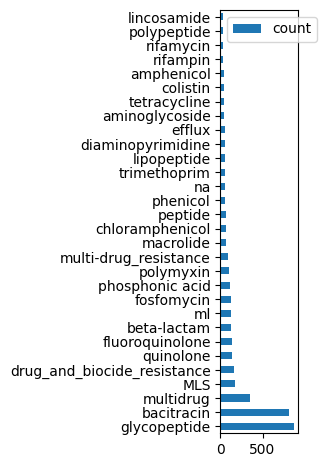

In [48]:
ClassCount = []
for item in pd.Series(DivergenteAnnotatedClasses):
    for c in item:
        ClassCount.append(c)
pd.Series(ClassCount).value_counts().head(30).to_frame().plot(kind = "barh", figsize=(1,5.5))

<Axes: >

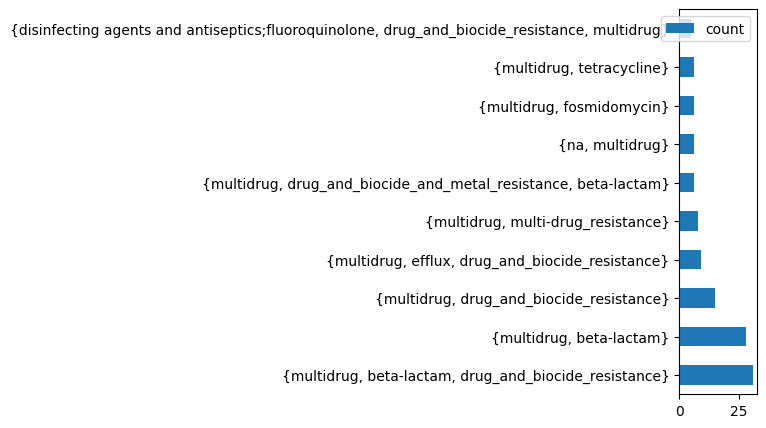

In [49]:
TargetClass = "multidrug"
pd.Series([c for c in DivergenteAnnotatedClasses if TargetClass in c]).value_counts().head(10).to_frame().plot(kind = "barh", figsize=(1,5))

In [53]:
TargetClass = "multidrug"
ProblematicCompWithTargetClass = set()
for key, value in ComponentIndex.items():
    if value["status"] == "problematic":
        if TargetClass in value["classes"]:
            ProblematicCompWithTargetClass = ProblematicCompWithTargetClass.union(value["component"])
ProblematicComponentsByClass = SequenceSimilarityGraph.subgraph(ProblematicCompWithTargetClass)
meu_layout = {
    "scalingRatio": 50.0,           # Aumente para afastar os grupos
    "gravity": 0.2,                 # Reduza para não amontoar no centro
    "repulsion": 2,               # Aumente para afastar os nós
    # "outboundAttractionDistribution": True, # Empurra hubs para fora
    # "barnesHutOptimize": True,      # Essencial para seus 70k nós
    # "linLogMode": True              # Melhora a definição de clusters biológicos 
}
Sigma(
    ProblematicComponentsByClass, 
    node_size  = ProblematicComponentsByClass.degree(), 
    node_color =  [ProblematicComponentsByClass.nodes[n].get("Drug Class") for n in ProblematicComponentsByClass.nodes()],
    # node_metrics={"community": "louvain"},

    default_edge_type = "curve",
    layout_settings=meu_layout,
    start_layout=30,
    )

Sigma(nx.Graph with 3,386 nodes and 8,847 edges)

In [55]:
SelectedCompIndex = None
NodeBait = "CARD_2015"
for key,value in ComponentIndex.items():
    if NodeBait in value["component"]:
        print("Selected component index:", key)
        SelectedCompIndex = key
        break

if SelectedCompIndex is None:
        raise ValueError(f"{NodeBait} not found in any component index.")

SelectedCluster = SelectedCompIndex

outdir = Path("../data/processed/selected_components")
outdir.mkdir(parents=True, exist_ok=True)

out_fasta = outdir / f"component_{SelectedCluster}_{NodeBait}.fasta"

def clean_fasta_field(value):
     """
     Clear fasta field for better visualization. If value is None, return "NA".
     """
     if value is None:
          return "NA"
     value = str(value).strip()
     value = re.sub(r'\s+', '_', value)  # Replace whitespace with underscores
     value = value.replace("|", "_")  # Replace pipe characters with underscores
     return value

with open(out_fasta, "w") as fasta_file:
     for protein in sorted(ComponentIndex[SelectedCluster]["component"]):
          drug_class = SequenceSimilarityGraph.nodes[protein].get("Drug Class", "NA")
          sequence = SequenceSimilarityGraph.nodes[protein].get("Sequence", "NA")

          drug_class_clean = clean_fasta_field(drug_class)

          fasta_file.write(f">{protein}|{drug_class_clean}\n")

          for line in wrap(sequence, width=80):
               fasta_file.write(line + "\n")

print (f"Fasta file for component {SelectedCluster} containing {NodeBait} has been saved to: {out_fasta}")

# StringFasta = []
# for protein in ComponentIndex[SelectedCluster]["component"]:
#     print(f">{protein}|{ProblematicComponentsByClass.nodes[protein]['Drug Class']}\n{ProblematicComponentsByClass.nodes[protein]['Sequence']}")
#     StringFasta.append(f">{protein}|{ProblematicComponentsByClass.nodes[protein]['Drug Class']}\n{ProblematicComponentsByClass.nodes[protein]['Sequence']}")

Selected component index: 1016
Fasta file for component 1016 containing CARD_2015 has been saved to: ../data/processed/selected_components/component_1016_CARD_2015.fasta


In [38]:
ProblematicComponentsByClass

In [39]:
ProblematicCompoLenDist = [value["len"] for key, value in ComponentIndex.items() if value["status"] == "problematic"]

Text(0.5, 1.0, 'Distribution of Problematic Component Sizes')

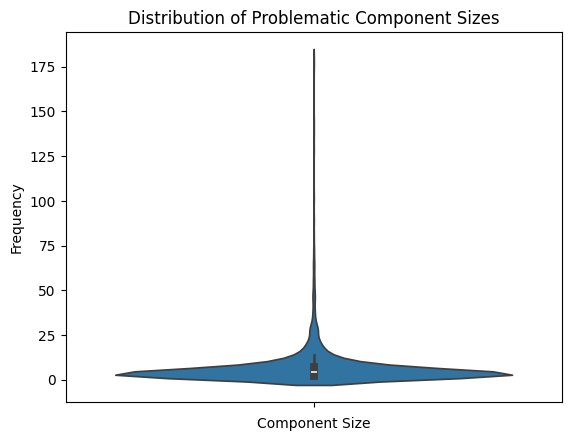

In [40]:
sns.violinplot(ProblematicCompoLenDist)
plt.xlabel("Component Size")
plt.ylabel("Frequency")
plt.title("Distribution of Problematic Component Sizes")

In [41]:
ProblematicCompoClassDist = [len(value["classes"]) for key, value in ComponentIndex.items() if value["status"] == "problematic"]

Text(0.5, 1.0, 'Distribution of Number of Classes in Problematic Component Sizes')

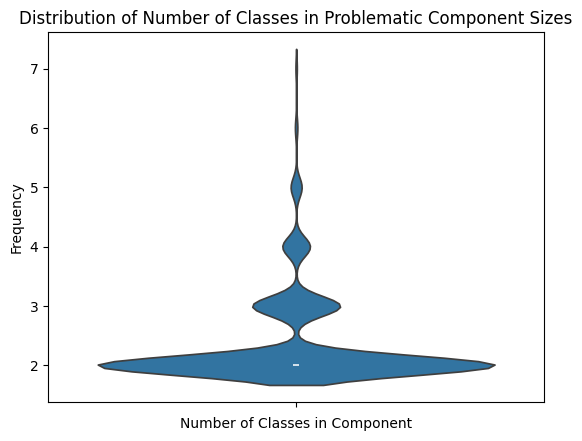

In [42]:
sns.violinplot(ProblematicCompoClassDist)
plt.xlabel("Number of Classes in Component")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Classes in Problematic Component Sizes")

In [43]:
def ConcateComponentsBy(CompDict, OriginalGraph, Minsize = None, MinClassNumber = None):
    if Minsize is None and MinClassNumber is None:
        raise ValueError("At least one of Minsize or MinClassNumber must be provided. Both cannot be None.")
    elif Minsize is not None and MinClassNumber is not None:
        raise ValueError("Only one of Minsize or MinClassNumber can be provided. Both cannot be set at the same time.")
    
    ConcateComponents = set()
    for key, value in CompDict.items():
        if Minsize is not None and value["len"] >= Minsize and value["status"] == "problematic":
            ConcateComponents = ConcateComponents.union(value["component"])

        elif MinClassNumber is not None and len(value["classes"]) >= MinClassNumber and value["status"] == "problematic":
            ConcateComponents = ConcateComponents.union(value["component"])            
    return OriginalGraph.subgraph(ConcateComponents),ConcateComponents

In [57]:
# ProblematicSubGraph, ConcateComponents = ConcateComponentsBy(ComponentIndex, SequenceSimilarityGraph, MinClassNumber = 3)
# meu_layout = {
#     "scalingRatio": 50.0,           # Aumente para afastar os grupos
#     "gravity": 0.2,                 # Reduza para não amontoar no centro
#     "repulsion": 2,               # Aumente para afastar os nós
#     # "outboundAttractionDistribution": True, # Empurra hubs para fora
#     # "barnesHutOptimize": True,      # Essencial para seus 70k nós
#     # "linLogMode": True              # Melhora a definição de clusters biológicos 
# }
# Sigma(
#     ProblematicSubGraph, 
#     node_size  = ProblematicSubGraph.degree(), 
#     node_color =  [ProblematicSubGraph.nodes[n].get("Drug Class") for n in ProblematicSubGraph.nodes()],
#     # node_metrics={"community": "louvain"},

#     default_edge_type = "curve",
#     layout_settings=meu_layout,
#     start_layout=30,
#     )

In [58]:
# ProblematicSubGraph, ConcateComponents = ConcateComponentsBy(ComponentIndex, SequenceSimilarityGraph, Minsize = 10)
# meu_layout = {
#     "scalingRatio": 50.0,           # Aumente para afastar os grupos
#     "gravity": 0.2,                 # Reduza para não amontoar no centro
#     "repulsion": 2,               # Aumente para afastar os nós
#     # "outboundAttractionDistribution": True, # Empurra hubs para fora
#     # "barnesHutOptimize": True,      # Essencial para seus 70k nós
#     # "linLogMode": True              # Melhora a definição de clusters biológicos 
# }
# Sigma(
#     ProblematicSubGraph, 
#     node_size  = ProblematicSubGraph.degree(), 
#     node_color =  [ProblematicSubGraph.nodes[n].get("Drug Class") for n in ProblematicSubGraph.nodes()],
#     # node_metrics={"community": "louvain"},

#     default_edge_type = "curve",
#     layout_settings=meu_layout,
#     start_layout=30,
#     )

In [59]:
ComponentIndex

{0: {'status': 'ok',
  'component': {'CARD_0',
   'HMD_11487',
   'HMD_12623',
   'HMD_4222',
   'HMD_8208',
   'HMD_9529',
   'MEGARES_1086',
   'MEGARES_1087',
   'NCRD_16945',
   'NDARO_1066'},
  'classes': {'beta-lactam'},
  'len': 10},
 1: {'status': 'ok',
  'component': {'CARD_1',
   'HMD_829',
   'MEGARES_4627',
   'NDARO_8793',
   'NDARO_8827',
   'RESFINDER_1099'},
  'classes': {'beta-lactam'},
  'len': 6},
 2: {'status': 'problematic',
  'component': {'CARD_2',
   'NCRD_0',
   'NCRD_18559',
   'NCRD_21335',
   'NCRD_8349',
   'NDARO_1354'},
  'classes': {'diaminopyrimidine', 'trimethoprim'},
  'len': 6},
 3: {'status': 'ok',
  'component': {'CARD_3',
   'HMD_1374',
   'MEGARES_1622',
   'NDARO_4551',
   'RESFINDER_599'},
  'classes': {'beta-lactam'},
  'len': 5},
 4: {'status': 'ok',
  'component': {'CARD_4',
   'HMD_247',
   'MEGARES_2711',
   'NDARO_5885',
   'RESFINDER_1518'},
  'classes': {'beta-lactam'},
  'len': 5},
 5: {'status': 'ok',
  'component': {'CARD_5',
   'HMD

885


>NCRD_8930|glycopeptide
MKIAISGTGYVGLSNGLLIAQQHEVIALDIIPERVQMLNARKSPIVDKEIEQYLKLDTIRFKATVDKELAYKDADFVIIATPTDYDPKTNYFNTTSVESVIDDVVRVNPSAVMVIKSTVPVGFTDAMKKKFGTENIIFSPEFLREGKALYDNLHPSRIVIGERSARAEKFASLLQQGAIKQNIPVLFTDSTEAEAIKLFANTYLAMRVAYFNELDSYAESLGLNTRQIIEGVCLDPRIGNHYNNPSFGYGGYCLPKDTKQLLANYQSVPNNIISAIVDANRTRKDFIADSILARQPKVVGIYRLIMKSGSDNFRASSIQGIMKRIKAKGIPVIIYEPVMQEDSFFNSRVVRDLDAFKEEADVIISNRMAEELIDVADKVYTRDLFGND
>NCRD_12942|glycopeptide
MKITISGTGYVGLSNGLLIAQNHEVVALDILPSRVAMLNDRISPIVDKEIQQFLQSDEIHFNATLGKVRTS
>NCRD_21911|glycopeptide
MKITISGTGYVGLSNGLLIAQNHEVVALDILPSRVAMLNDRISPIVDKEIQQFLQSDKIHFNATLDKNEAYRDADYVIIATPTDYDPKTNYFNTSSVESVIKDVVEINPYAVMVIKSTVPVGFTAAMHKKYRTENIIFSPEFLREGKALYDNLHPSRIVIGERSERAERFAALLQEGAIKQDIPTLFTDSTEAEAIKLFANTYLALRVAYFNELDSYAESQGLNSKQIIEGVCLDPRIGNHYNNPSFGYGGYCLPKDTKQLLANYESVPNNIIAAIVDANRTRKDFIADSILARKPKVVGVYRLIMKSGSDNFRASSIQGIMKRIKAKGIPVIIYEPVMQEDEFFNSRVVRDLDTFKQEADVIISNRMAEELADVADKVYTRDLFGSD
>NCRD_18205|glycopeptide
MKITISGTGYVGLSNGLLIAQNHEVVALDILPSRVAMLNDRISPIVDKEIL

In [62]:
AlignedComponent = Align.ProteinAligner(StringFasta)

In [63]:
for i, seq in enumerate(AlignedComponent):
    print(f">{seq.id}")
    print(seq.seq)

>NCRD_8930|glycopeptide
MKIAISGTGYVGLSNGLLIAQQHEVIALDIIPERVQMLNARKSPIVDKEIEQYLKLDTIRFKATVDKELAYKDADFVIIATPTDYDPKTNYFNTTSVESVIDDVVRVNPSAVMVIKSTVPVGFTDAMKKKFGTENIIFSPEFLREGKALYDNLHPSRIVIGERSARAEKFASLLQQGAIKQNIPVLFTDSTEAEAIKLFANTYLAMRVAYFNELDSYAESLGLNTRQIIEGVCLDPRIGNHYNNPSFGYGGYCLPKDTKQLLANYQSVPNNIISAIVDANRTRKDFIADSILARQPKVVGIYRLIMKSGSDNFRASSI---QGIMKRIKAKGIPVIIYEPVMQEDSFFNSRVVRDLDAFKEEADVIISNRMAEELIDVADKVYT------------------------RDLFGND-------------------
>NCRD_12942|glycopeptide
MKITISGTGYVGLSNGLLIAQNHEVVALDILPSRVAMLNDRISPIVDKEIQQFLQSDEIHFNATLGK-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------VRTS----------------------------------------------------------------------------------------------------------------------
>NCRD_21911|glycopeptide
MKITISGTGYVGLSNGLLIAQNHEVVALDILPSRVAMLNDRISPIVDKEIQQFLQS